In [1]:
# ============================================
# IMPORTS Y CONFIGURACIÓN GENERAL
# ============================================
import os

# Asegurarse de que estemos parados en la raíz del proyecto,
# sin importar desde dónde Jupyter haya iniciado el kernel
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Directorio de trabajo actual:", os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Estructura de carpetas del proyecto local
base = "."
carpetas = ["data", "notebooks", "models", "images"]
for c in carpetas:
    os.makedirs(os.path.join(base, c), exist_ok=True)

print("Carpetas creadas:", os.listdir(base))

Directorio de trabajo actual: /home/nibbs/dev/vs code ML avanzado/red_neuronal


I0000 00:00:1789270165.092447  117918 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789270165.188804  117918 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789270167.586247  117918 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Carpetas creadas: ['.gitignore', 'notebooks', 'venv', '.git', 'data', 'models', 'images', 'README.md']


DESCARGAR EL DATASET

In [2]:
import os

os.makedirs("data", exist_ok=True)

!kaggle datasets download -d puneet6060/intel-image-classification -p data
!unzip -q -o data/intel-image-classification.zip -d data/intel_images

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100%|███████████████████████████████████████| 346M/346M [00:18<00:00, 20.0MB/s]



In [3]:
base_dir = "intel_images"
train_dir = os.path.join(base_dir, "seg_train", "seg_train")
test_dir  = os.path.join(base_dir, "seg_test", "seg_test")

print(os.listdir(train_dir))  # debería mostrar las 6 clases

FileNotFoundError: [Errno 2] No such file or directory: 'intel_images/seg_train/seg_train'

EDA

Clases: ['buildings', 'forest', 'glacier']


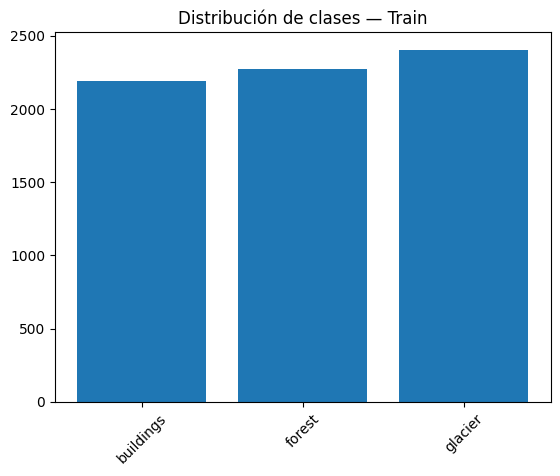

{'buildings': 2191, 'forest': 2271, 'glacier': 2404}


In [4]:
#clases = sorted(os.listdir(train_dir))
clases = ["buildings", "forest", "glacier"]
print("Clases:", clases)

# Conteo de imágenes por clase
conteo = {c: len(os.listdir(os.path.join(train_dir, c))) for c in clases}
plt.bar(conteo.keys(), conteo.values())
plt.title("Distribución de clases — Train")
plt.xticks(rotation=45)
plt.savefig(f"{base}/images/distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()
print(conteo)

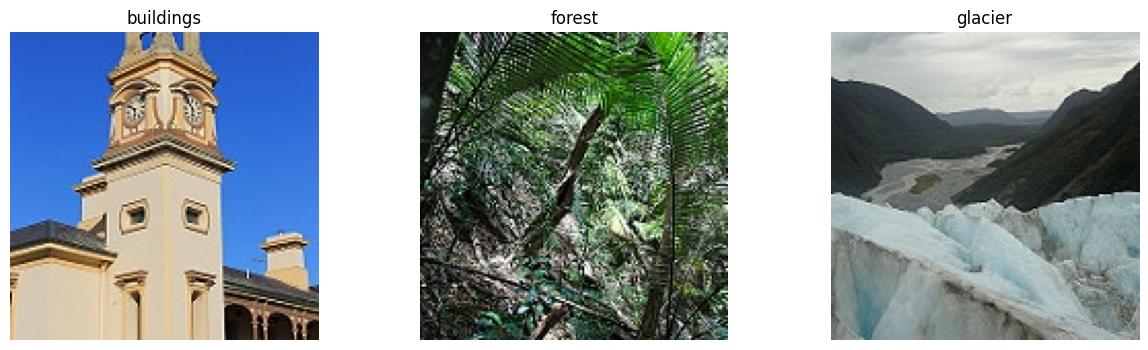

In [5]:
# Mostrar ejemplos por clase
fig, axes = plt.subplots(1, len(clases), figsize=(15, 4))
for ax, c in zip(axes, clases):
    ejemplo = os.listdir(os.path.join(train_dir, c))[0]
    img = Image.open(os.path.join(train_dir, c, ejemplo))
    ax.imshow(img)
    ax.set_title(c)
    ax.axis("off")
plt.show()

In [6]:
# Revisar tamaños de imagen (Intel NO siempre es 150x150 exacto)
tamaños = []
for c in clases:
    for f in os.listdir(os.path.join(train_dir, c))[:50]:
        img = Image.open(os.path.join(train_dir, c, f))
        tamaños.append(img.size)
print(set(tamaños))

{(150, 115), (150, 150)}


PREPARACION Y PROCESAMIENTO

In [7]:
IMG_SIZE = 64  # reducir resolución acelera mucho el entrenamiento de un MLP
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    classes=clases,       # si usan subconjunto, filtra solo esas carpetas
    seed=42
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    classes=clases,
    seed=42
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=clases,
    shuffle=False
)

Found 5494 images belonging to 3 classes.
Found 1372 images belonging to 3 classes.
Found 1464 images belonging to 3 classes.


DISEÑO DEL PERCEPTRON MULTICAPA

In [8]:
n_clases = len(clases)

# Flatter aplana la imagen a 64x64x3 = 12.288 valores, vector largo
modelo = Sequential([
    Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Dense(256, activation="relu"), # primera capa oculta, 256 neuronas
    Dropout(0.3),
    # Dropout no es una capa de neuronas,
    # apaga aleatoriamente el 30% de las conexiones durante el
    # entrenamiento (técnica para evitar el overfitting)
    Dense(128, activation="relu"), # segunda capa oculta, 128 neuronas
    Dense(n_clases, activation="softmax") # capa de salida
])

modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,267 (12.13 MB)

 Trainable params: 3,179,267 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

ENTRENAMIENTO

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = modelo.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.5888 - loss: 1.0902 - val_accuracy: 0.7230 - val_loss: 0.6536
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.6762 - loss: 0.7292 - val_accuracy: 0.7055 - val_loss: 0.6877
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.6391 - loss: 0.7573 - val_accuracy: 0.7187 - val_loss: 0.6679
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.6744 - loss: 0.6990 - val_accuracy: 0.7449 - val_loss: 0.6253
Epoch 5/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.6736 - loss: 0.7035 - val_accuracy: 0.7653 - val_loss: 0.5934
Epoch 6/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.7166 - loss: 0.6413 - val_accuracy: 0.7558 - val_loss: 0.5748
Epoch 7/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.6977 - loss: 0.6473 - val_accuracy: 0.7456 - val_loss: 0.6574
Epoch 8/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.7368 - loss: 0.6047 - 

In [ ]:
modelo.save(f"{base}/models/modelo_mlp.keras")

In [ ]:
## Loss / Accuracy
hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(7,4))
plt.plot(hist_df["loss"], label="train loss")
plt.plot(hist_df["val_loss"], label="val loss")
plt.legend(); plt.title("Pérdida")
plt.savefig(f"{base}/images/curva_loss.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist_df["accuracy"], label="train acc")
plt.plot(hist_df["val_accuracy"], label="val acc")
plt.legend(); plt.title("Accuracy")
plt.savefig(f"{base}/images/curva_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

EVALUACION DEL DESEMPEÑO

In [ ]:
y_true = test_gen.classes
y_pred_probs = modelo.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro"))
print("Recall   :", recall_score(y_true, y_pred, average="macro"))
print("F1       :", f1_score(y_true, y_pred, average="macro"))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clases, yticklabels=clases, cmap="Blues")
plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title("Matriz de confusión")
plt.savefig(f"{base}/images/matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=clases))

ANALISIS DE ERRORES Y LIMTACIONES

In [ ]:
errores_idx = np.where(y_pred != y_true)[0][:9]
filenames = test_gen.filenames

fig, axes = plt.subplots(3, 3, figsize=(10,10))
for ax, idx in zip(axes.ravel(), errores_idx):
    img = plt.imread(os.path.join(test_dir, filenames[idx]))
    ax.imshow(img)
    ax.set_title(f"Real: {clases[y_true[idx]]}\nPred: {clases[y_pred[idx]]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{base}/images/errores_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()